In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import keras
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Convolution2D, MaxPooling2D
from sklearn.model_selection import train_test_split
import warnings
import seaborn as sns
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd drive/MyDrive/Colab\ Notebooks/COGS\ 189/

/content/drive/MyDrive/Colab Notebooks/COGS 189


In [ ]:
data = pd.read_csv("eeg_data.csv")

In [ ]:
data.head()

,# mean_0_a,mean_1_a,mean_2_a,mean_3_a,mean_4_a,mean_d_0_a,mean_d_1_a,mean_d_2_a,mean_d_3_a,mean_d_4_a,...,fft_741_b,fft_742_b,fft_743_b,fft_744_b,fft_745_b,fft_746_b,fft_747_b,fft_748_b,fft_749_b,label
0,4.62,30.3,-356.0,15.6,26.3,1.070,0.411,-15.70,2.06,3.15,...,23.5,20.3,20.3,23.5,-215.0,280.00,-162.00,-162.00,280.00,NEGATIVE
1,28.80,33.1,32.0,25.8,22.8,6.550,1.680,2.88,3.83,-4.82,...,-23.3,-21.8,-21.8,-23.3,182.0,2.57,-31.60,-31.60,2.57,NEUTRAL
2,8.90,29.4,-416.0,16.7,23.7,79.900,3.360,90.20,89.90,2.03,...,462.0,-233.0,-233.0,462.0,-267.0,281.00,-148.00,-148.00,281.00,POSITIVE
3,14.90,31.6,-143.0,19.8,24.3,-0.584,-0.284,8.82,2.30,-1.97,...,299.0,-243.0,-243.0,299.0,132.0,-12.40,9.53,9.53,-12.40,POSITIVE
4,28.30,31.3,45.2,27.3,24.5,34.800,-5.790,3.06,41.40,5.52,...,12.0,38.1,38.1,12.0,119.0,-17.60,23.90,23.90,-17.60,NEUTRAL


In [ ]:
eeg_data_columns = data.columns.values.tolist()

In [ ]:
print(data["label"].value_counts())
cleanup_rules = ({'NEUTRAL': 0, 'POSITIVE': 1, 'NEGATIVE': 2} )
eeg_data_encoded = data.replace(cleanup_rules, inplace=False)
print(eeg_data_encoded['label'].value_counts())

label
NEUTRAL     716
NEGATIVE    708
POSITIVE    708
Name: count, dtype: int64
label
0    716
2    708
1    708
Name: count, dtype: int64


In [ ]:
x = data.drop(columns=['label'])
y = eeg_data_encoded.label

In [ ]:
y.head()

,label
0,2
1,0
2,1
3,1
4,0


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.20)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
estimator = RandomForestClassifier(n_estimators=100, max_depth=2, random_state=0)
estimator.fit(X_train, y_train)

RandomForestClassifier(max_depth=2, random_state=0)

In [ ]:
mean_accuracy=estimator.score(X_test, y_test)
y_pred = estimator.predict(X_test)
print(mean_accuracy)
print(estimator.feature_importances_)

0.9320843091334895
[0.00623949 0.00395458 0.01040646 ... 0.         0.         0.        ]


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[127   2   0]
 [  0 124  26]
 [  0   1 147]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       129
           1       0.98      0.83      0.90       150
           2       0.85      0.99      0.92       148

    accuracy                           0.93       427
   macro avg       0.94      0.93      0.93       427
weighted avg       0.94      0.93      0.93       427



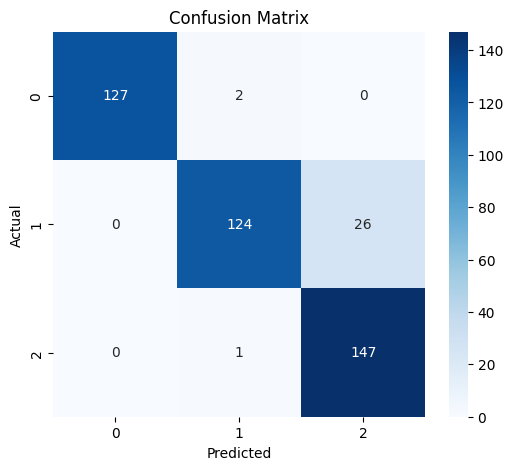

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

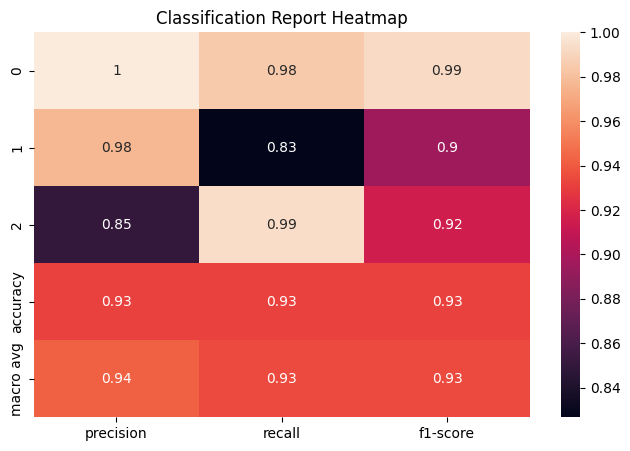

In [ ]:
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
df = pd.DataFrame(report).transpose()

plt.figure(figsize=(8,5))
sns.heatmap(df.iloc[:-1, :-1], annot=True)
plt.title("Classification Report Heatmap")
plt.show()

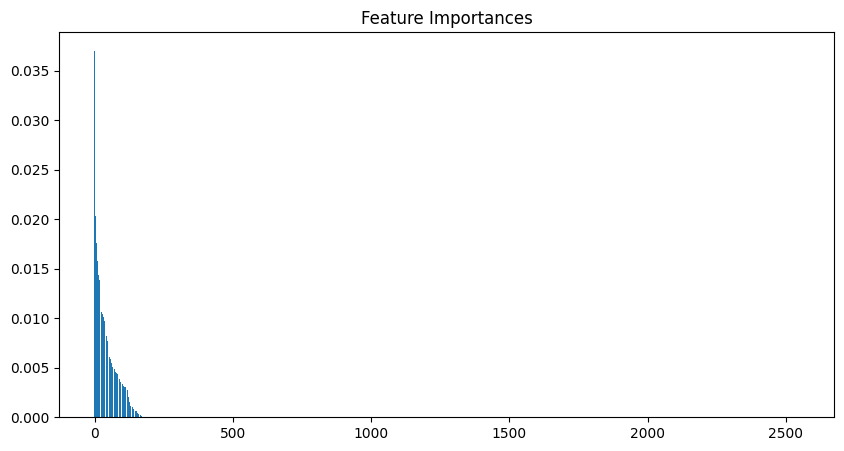

In [ ]:
import numpy as np

importances = estimator.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,5))
plt.title("Feature Importances")
plt.bar(range(len(importances)), importances[indices])
plt.show()

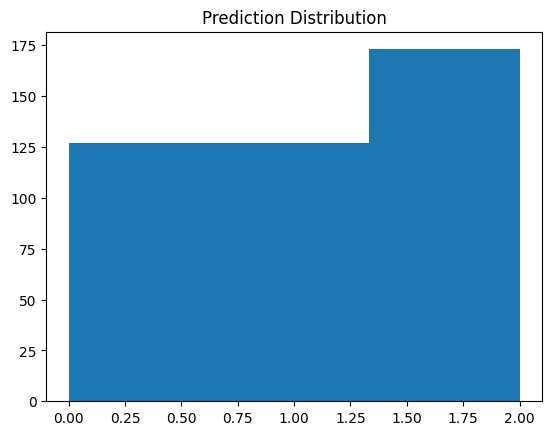

In [ ]:
plt.hist(y_pred, bins=len(set(y_pred)))
plt.title("Prediction Distribution")
plt.show()